
# Stage 1 — DR Screening Pipeline: Quality Classifier (EyeQ)

**Fast/subset mode for Colab free tier.** This version trains on a *stratified subset*
of EyeQ instead of the full 28,792 images, adds mixed precision, in-memory image caching,
a progressive-unfreeze warm-up, and a resume-from-checkpoint path — aimed at fitting
comfortably inside a single free-tier Colab session while keeping accuracy close to a
full-dataset run. Final evaluation still runs on the **full official EyeQ test split**,
so the reported number stays comparable to the MCF-Net ~0.88 baseline.

Trains the **Stage 1 quality gate** from the POC architecture: a 3-class classifier
(`Good` / `Usable` / `Reject`) on the **EyeQ** dataset, using EyeQ's own official
train/test split so results are comparable to the MCF-Net paper's ~0.88 accuracy baseline.

**Output of this notebook** (saved to your Drive, ready to drop into the FastAPI service):
```
stage1_quality/
├── model.pt              # trained weights
├── config.json            # architecture, class mapping, preprocessing params
├── training_history.json  # loss/accuracy curves
└── eval_report.json       # test-set metrics vs baseline
```

**Before running:** update the paths in the `CONFIG` cell below to match how you organized
the EyeQ dataset in your Google Drive (image folders + `Label_EyeQ_train.csv` /
`Label_EyeQ_test.csv`). Also sanity-check the new **FAST / SUBSET MODE** block in `CONFIG` —
that's the part that controls how much data you train on and how long it'll take.


## 1. Setup

In [ ]:
# Colab GPU check — Runtime > Change runtime type > GPU (T4 is fine)
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader


Tesla T4, 15360 MiB


In [ ]:
!pip install -q timm scikit-learn opencv-python-headless tqdm


In [ ]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as T
import timm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True  # inputs are a fixed size -> let cuDNN autotune kernels
print("Device:", device)


Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 2. Config

Edit these paths to match your Drive layout. Everything downstream reads from here —
no other cell should need path edits.

- `TRAIN_CSV` / `TEST_CSV`: EyeQ's official `Label_EyeQ_train.csv` / `Label_EyeQ_test.csv`
- `TRAIN_IMG_DIR` / `TEST_IMG_DIR`: folders containing the actual EyePACS images referenced by those CSVs
- `OUTPUT_DIR`: where trained artifacts get saved on Drive (persists across Colab sessions)

**New — FAST / SUBSET MODE**: since the full EyeQ set is too big to train on repeatedly
within a free-tier Colab session, training runs on a *stratified subset* (`MAX_TRAIN_SAMPLES`)
with a small held-out subset (`MAX_VAL_SAMPLES`) for fast per-epoch monitoring. The final
reported accuracy (Section 8) still runs on the **full official test split**, so it stays
comparable to the paper baseline even though training itself was faster. Tune the sizes
based on the timing dry-run in Section 6.


In [ ]:
CONFIG = {
    # ---- dataset paths (EDIT THESE) ----
    "TRAIN_CSV": "/content/drive/MyDrive/DR HACK/eyeq_dataset/Label_EyeQ_train.csv",
    "TEST_CSV": "/content/drive/MyDrive/DR HACK/eyeq_dataset/Label_EyeQ_test.csv",
    "TRAIN_IMG_DIR": "/content/drive/MyDrive/DR HACK/eyeq_dataset/train_images",
    "TEST_IMG_DIR": "/content/drive/MyDrive/DR HACK/eyeq_dataset/test_images",

    # ---- output (EDIT if you want a different Drive location) ----
    "OUTPUT_DIR": "/content/drive/MyDrive/dr_screening_pipeline/stage1_quality",

    # ---- model ----
    # any timm model name works; these two match the architecture doc
    "MODEL_ARCH": "efficientnet_b0",   # or "mobilenetv3_small_100" (even faster, slightly lower ceiling)
    "IMG_SIZE": 224,
    "NUM_CLASSES": 3,

    # ---- training ----
    "BATCH_SIZE": 64,               # T4 handles EfficientNet-B0 @224 comfortably at 64 with AMP
    "EPOCHS": 15,
    "LR": 3e-4,
    "WEIGHT_DECAY": 1e-4,
    "EARLY_STOP_PATIENCE": 4,
    "NUM_WORKERS": 2,                # Colab free tier gives ~2 vCPUs
    "PREFETCH_FACTOR": 4,

    # ---- FAST / SUBSET MODE (Colab free tier) ----
    # Train on a stratified subset instead of the full 28.8k-image EyeQ set.
    # Final evaluation (Section 8) always runs on the FULL official test split
    # regardless of these settings, so the reported number stays comparable
    # to the MCF-Net baseline below.
    "USE_SUBSET": True,
    "MAX_TRAIN_SAMPLES": 6000,      # ~20% of EyeQ's train split — see the timing dry-run before committing
    "MAX_VAL_SAMPLES": 1200,        # small held-out slice used every epoch just for monitoring/early-stop
    "MIN_PER_CLASS": 150,           # floor so the minority ("Reject") class isn't starved by proportional sampling
    "SUBSET_SEED": 42,

    # ---- speed ----
    "USE_AMP": True,                # mixed precision — ~1.5-2x speedup on T4, negligible accuracy impact
    "CACHE_IMAGES_IN_MEMORY": True, # decode+resize once, keep in RAM — avoids re-hitting slow Drive I/O every epoch
    "FREEZE_BACKBONE_EPOCHS": 3,    # first N epochs: train the classifier head only (fast warm-up, less overfit on a small subset)
    "TIME_BUDGET_MINUTES": 150,     # soft budget — training loop checkpoints and stops cleanly if you're about to blow past this

    # ---- baseline to beat (MCF-Net paper) ----
    "BASELINE_ACCURACY": 0.88,
}

Path(CONFIG["OUTPUT_DIR"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG, indent=2))


{
  "TRAIN_CSV": "/content/drive/MyDrive/DR HACK/eyeq_dataset/Label_EyeQ_train.csv",
  "TEST_CSV": "/content/drive/MyDrive/DR HACK/eyeq_dataset/Label_EyeQ_test.csv",
  "TRAIN_IMG_DIR": "/content/drive/MyDrive/DR HACK/eyeq_dataset/train_images",
  "TEST_IMG_DIR": "/content/drive/MyDrive/DR HACK/eyeq_dataset/test_images",
  "OUTPUT_DIR": "/content/drive/MyDrive/dr_screening_pipeline/stage1_quality",
  "MODEL_ARCH": "efficientnet_b0",
  "IMG_SIZE": 224,
  "NUM_CLASSES": 3,
  "BATCH_SIZE": 64,
  "EPOCHS": 15,
  "LR": 0.0003,
  "WEIGHT_DECAY": 0.0001,
  "EARLY_STOP_PATIENCE": 4,
  "NUM_WORKERS": 2,
  "PREFETCH_FACTOR": 4,
  "USE_SUBSET": true,
  "MAX_TRAIN_SAMPLES": 6000,
  "MAX_VAL_SAMPLES": 1200,
  "MIN_PER_CLASS": 150,
  "SUBSET_SEED": 42,
  "USE_AMP": true,
  "CACHE_IMAGES_IN_MEMORY": true,
  "FREEZE_BACKBONE_EPOCHS": 3,
  "TIME_BUDGET_MINUTES": 150,
  "BASELINE_ACCURACY": 0.88
}


## 3. Load labels & inspect columns

EyeQ's CSV column names vary slightly across releases (`quality`, `Overall_quality`, `DR_grade`, etc.), so we inspect first rather than assuming names, then map them explicitly in the next cell.

In [ ]:
train_df_raw = pd.read_csv(CONFIG["TRAIN_CSV"])
test_df_raw = pd.read_csv(CONFIG["TEST_CSV"])

print("TRAIN columns:", list(train_df_raw.columns))
print("TRAIN shape:", train_df_raw.shape)
train_df_raw.head()


TRAIN columns: ['Unnamed: 0', 'image', 'quality', 'DR_grade']
TRAIN shape: (12543, 4)


,Unnamed: 0,image,quality,DR_grade
0,0,10009_left.jpeg,0,0
1,1,10009_right.jpeg,0,0
2,2,10014_left.jpeg,2,0
3,3,10014_right.jpeg,2,0
4,4,10015_left.jpeg,0,0


### Column mapping

Set these two cells based on what you saw printed above. EyeQ's original release uses
something like:
- an image filename column (e.g. `image`)
- a quality label column with integer codes **0 = Good, 1 = Usable, 2 = Reject**
- a `DR_grade` column (0–4) — not used in this notebook, that's Stage 3's job

Adjust the strings below to match your actual CSV headers.


In [ ]:
COLMAP = {
    "filename_col": "image",          # column holding the image filename
    "quality_col": "quality",         # column holding 0/1/2 quality code
}

# EyeQ's standard code -> label mapping (edit only if your CSV differs)
QUALITY_LABELS = {0: "Good", 1: "Usable", 2: "Reject"}
LABEL_TO_IDX = {v: k for k, v in QUALITY_LABELS.items()}

assert COLMAP["filename_col"] in train_df_raw.columns, \
    f"'{COLMAP['filename_col']}' not found — check the printed columns above and update COLMAP"
assert COLMAP["quality_col"] in train_df_raw.columns, \
    f"'{COLMAP['quality_col']}' not found — check the printed columns above and update COLMAP"

train_df = train_df_raw[[COLMAP["filename_col"], COLMAP["quality_col"]]].copy()
train_df.columns = ["filename", "label"]

test_df = test_df_raw[[COLMAP["filename_col"], COLMAP["quality_col"]]].copy()
test_df.columns = ["filename", "label"]

print("Train class distribution:")
print(train_df["label"].map(QUALITY_LABELS).value_counts())
print("\nTest class distribution:")
print(test_df["label"].map(QUALITY_LABELS).value_counts())


Train class distribution:
label
Good      8347
Reject    2320
Usable    1876
Name: count, dtype: int64

Test class distribution:
label
Good      8471
Usable    4558
Reject    3220
Name: count, dtype: int64


### Stratified subsampling for fast Colab training

Keeps the full official splits around (`train_df_full`, `test_df_full` — needed for the
final, baseline-comparable evaluation in Section 8), then carves out:
- `train_df` — a stratified subset used for every training epoch
- `val_df` — a small stratified subset of the test split, used for fast per-epoch monitoring
  and early stopping (NOT the number you report — that's the full test set later)

Sampling is proportional to each class's natural frequency, with a floor (`MIN_PER_CLASS`)
so the minority `Reject` class doesn't get starved.


In [ ]:
# Keep references to the full official splits — needed later, since the final
# evaluation (Section 8) must run on the FULL test split to stay comparable to
# the MCF-Net baseline, even though training itself uses a smaller subset.
train_df_full = train_df.copy()
test_df_full = test_df.copy()

def stratified_subsample(df, max_samples, min_per_class, seed):
    """Sample down to ~`max_samples` rows, preserving class proportions but
    guaranteeing at least `min_per_class` rows per class when that class has
    enough rows to support it. No-op if the subset would be >= the full df."""
    if not CONFIG["USE_SUBSET"] or len(df) <= max_samples:
        return df.reset_index(drop=True)

    class_counts = df["label"].value_counts()

    proportional = (class_counts / class_counts.sum() * max_samples).round().astype(int)
    target = {c: max(min_per_class, int(proportional.get(c, 0))) for c in class_counts.index}
    target = {c: min(target[c], int(class_counts[c])) for c in target}  # never exceed what's available

    total_target = sum(target.values())
    if total_target > max_samples:
        scale = max_samples / total_target
        target = {c: max(1, int(v * scale)) for c, v in target.items()}

    parts = []
    for c, n in target.items():
        pool = df[df["label"] == c]
        n = min(n, len(pool))
        parts.append(pool.sample(n=n, random_state=seed))

    out = pd.concat(parts).sample(frac=1.0, random_state=seed).reset_index(drop=True)  # shuffle
    return out

print(f"Full official split — train: {len(train_df_full)}, test: {len(test_df_full)}")

train_df = stratified_subsample(train_df_full, CONFIG["MAX_TRAIN_SAMPLES"], CONFIG["MIN_PER_CLASS"], CONFIG["SUBSET_SEED"])
val_df   = stratified_subsample(test_df_full,  CONFIG["MAX_VAL_SAMPLES"],   max(30, CONFIG["MIN_PER_CLASS"] // 3), CONFIG["SUBSET_SEED"])

print(f"\nTraining subset — train: {len(train_df)} (every epoch), val: {len(val_df)} (every epoch, monitoring only)")
print("Full official test split is reserved for the one-time final evaluation in Section 8.")

print("\nTrain class distribution (subset):")
print(train_df["label"].map(QUALITY_LABELS).value_counts())
print("\nVal class distribution (subset):")
print(val_df["label"].map(QUALITY_LABELS).value_counts())


Full official split — train: 12543, test: 16249

Training subset — train: 6000 (every epoch), val: 1198 (every epoch, monitoring only)
Full official test split is reserved for the one-time final evaluation in Section 8.

Train class distribution (subset):
label
Good      3993
Reject    1110
Usable     897
Name: count, dtype: int64

Val class distribution (subset):
label
Good      625
Usable    336
Reject    237
Name: count, dtype: int64


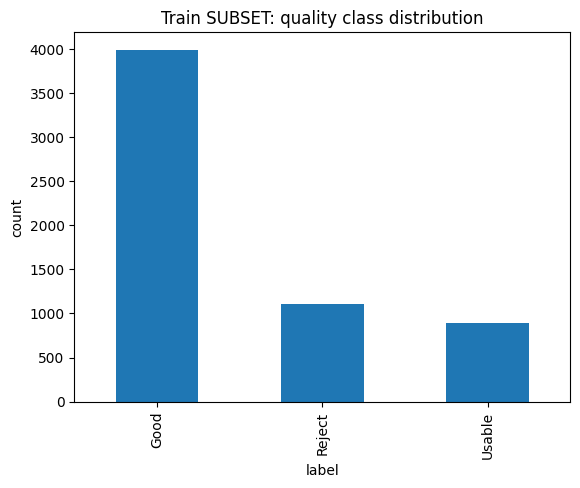

In [ ]:
train_df["label"].map(QUALITY_LABELS).value_counts().plot(kind="bar", title="Train SUBSET: quality class distribution")
plt.ylabel("count")
plt.show()


In [ ]:
def verify_images_exist(df, img_dir, n_check=20):
    missing = 0
    sample = df.sample(min(n_check, len(df)), random_state=SEED)
    for fn in sample["filename"]:
        p = Path(img_dir) / fn
        if not p.exists():
            # try common alt extensions in case CSV omits/mismatches extension
            alt = list(Path(img_dir).glob(Path(fn).stem + ".*"))
            if not alt:
                missing += 1
    print(f"{missing}/{len(sample)} sampled files missing in {img_dir}")

verify_images_exist(train_df, CONFIG["TRAIN_IMG_DIR"])
verify_images_exist(val_df, CONFIG["TEST_IMG_DIR"])


0/20 sampled files missing in /content/drive/MyDrive/DR HACK/eyeq_dataset/train_images
0/20 sampled files missing in /content/drive/MyDrive/DR HACK/eyeq_dataset/test_images


## 4. Fast classical pre-filters

From the architecture doc: cheap, sub-second blur/illumination checks that run *before*
the CNN in the deployed Stage-1 SLA. They're not used to train the model, but we compute
them here for EDA (are 'Reject' images actually catching blur/illumination problems?) and
export them so the FastAPI service can reuse identical logic.


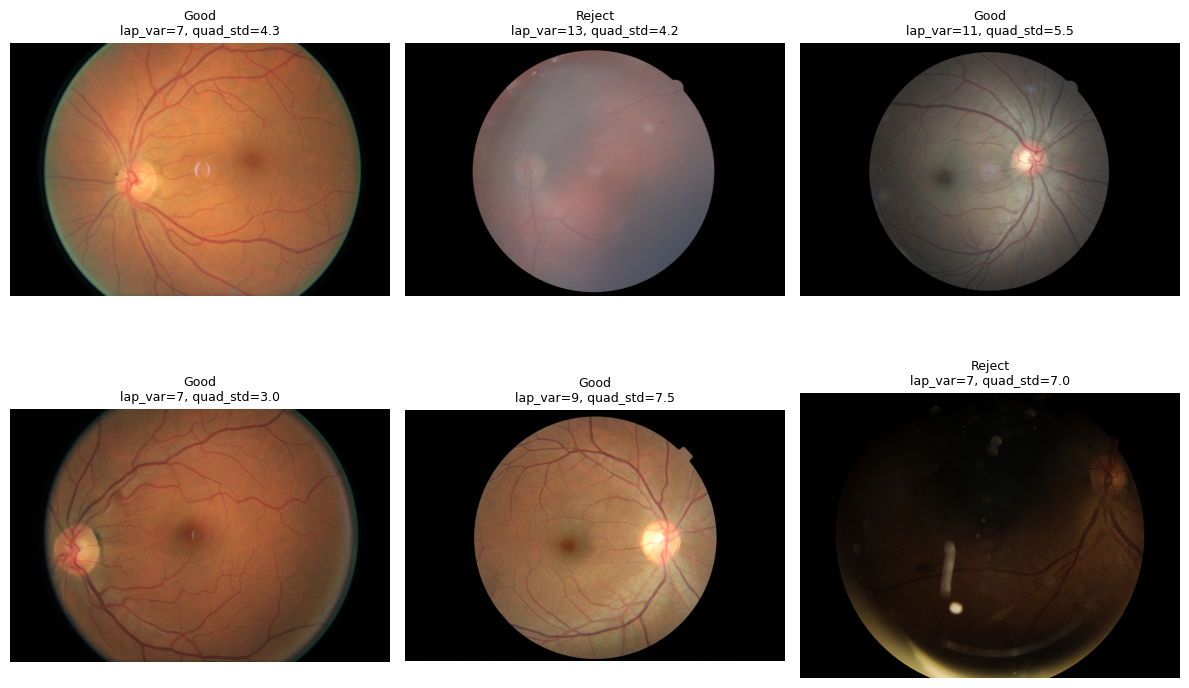

In [ ]:
def laplacian_variance(img_bgr):
    """Blur metric — lower variance = blurrier."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def quadrant_histogram_spread(img_bgr):
    """Illumination metric — spread of mean brightness across 4 quadrants."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    quads = [
        gray[0:h//2, 0:w//2], gray[0:h//2, w//2:w],
        gray[h//2:h, 0:w//2], gray[h//2:h, w//2:w],
    ]
    means = [q.mean() for q in quads]
    return float(np.std(means))

# Quick sanity check on a handful of train images
sample = train_df.sample(6, random_state=SEED)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    path = Path(CONFIG["TRAIN_IMG_DIR"]) / row["filename"]
    img = cv2.imread(str(path))
    if img is None:
        continue
    lv = laplacian_variance(img)
    qs = quadrant_histogram_spread(img)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{QUALITY_LABELS[row['label']]}\nlap_var={lv:.0f}, quad_std={qs:.1f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Dataset & DataLoaders

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

class EyeQDataset(Dataset):
    """Same as before, plus an optional in-memory cache. Path resolution now
    builds ONE directory index up front (instead of exists()+glob() per image,
    which was the real cost — a full glob() scan on every filename mismatch,
    repeated over Drive's FUSE mount). Caching also runs multi-threaded since
    cv2 I/O releases the GIL and Drive reads are latency-bound, not CPU-bound.
    """

    def __init__(self, df, img_dir, transform=None, cache_in_memory=False, num_workers=16):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.cache_in_memory = cache_in_memory
        self.num_workers = num_workers
        self._cache = None
        self._path_index = self._build_path_index()
        if cache_in_memory:
            self._build_cache()

    def _build_path_index(self):
        """Single directory listing, stem -> path. Replaces per-file exists()+glob()."""
        t0 = time.time()
        index = {}
        for p in self.img_dir.iterdir():
            if p.is_file():
                index[p.stem] = p
        print(f"Indexed {len(index)} files in {self.img_dir.name} in {time.time()-t0:.1f}s")
        return index

    def _resolve_path(self, filename):
        stem = Path(filename).stem
        p = self._path_index.get(stem)
        if p is not None:
            return p
        # exact filename fallback (covers rare stem collisions across extensions)
        exact = self.img_dir / filename
        if exact.exists():
            return exact
        raise FileNotFoundError(f"Image not found: {filename}")

    def _load_one(self, i, size):
        fn = self.df["filename"].iloc[i]
        path = self._resolve_path(fn)
        img = cv2.imread(str(path))
        if img is None:
            raise RuntimeError(f"cv2 failed to read {path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
        return i, img

    def _build_cache(self):
        size = CONFIG["IMG_SIZE"]
        n = len(self.df)
        print(f"Caching {n} images in memory ({size}x{size}, {self.num_workers} threads)...")
        t0 = time.time()
        cache = np.zeros((n, size, size, 3), dtype=np.uint8)
        done = 0
        with ThreadPoolExecutor(max_workers=self.num_workers) as ex:
            futures = [ex.submit(self._load_one, i, size) for i in range(n)]
            for fut in as_completed(futures):
                i, img = fut.result()
                cache[i] = img
                done += 1
                if done % 1000 == 0:
                    print(f"  cached {done}/{n}")
        self._cache = cache
        print(f"Done caching in {time.time() - t0:.1f}s ({cache.nbytes / 1e9:.2f} GB in RAM)")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        if self.cache_in_memory:
            img = self._cache[idx]
        else:
            path = self._resolve_path(row["filename"])
            img = cv2.imread(str(path))
            if img is None:
                raise RuntimeError(f"cv2 failed to read {path}")
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform:
            img = self.transform(img)

        label = int(row["label"])
        return img, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ToPIL:
    def __call__(self, arr):
        from PIL import Image
        return Image.fromarray(arr)

train_transform = T.Compose([
    ToPIL(),
    T.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    ToPIL(),
    T.Resize((CONFIG["IMG_SIZE"], CONFIG["IMG_SIZE"])),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = EyeQDataset(train_df, CONFIG["TRAIN_IMG_DIR"], transform=train_transform,
                             cache_in_memory=CONFIG["CACHE_IMAGES_IN_MEMORY"])
val_dataset = EyeQDataset(val_df, CONFIG["TEST_IMG_DIR"], transform=eval_transform,
                           cache_in_memory=CONFIG["CACHE_IMAGES_IN_MEMORY"])

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")

Indexed 12543 files in train_images in 6.8s
Caching 6000 images in memory (224x224, 16 threads)...
  cached 1000/6000
  cached 2000/6000
  cached 3000/6000
  cached 4000/6000
  cached 5000/6000
  cached 6000/6000
Done caching in 2054.1s (0.90 GB in RAM)
Indexed 16249 files in test_images in 4.9s
Caching 1198 images in memory (224x224, 16 threads)...
  cached 1000/1198
Done caching in 1532.6s (0.18 GB in RAM)
Train: 6000  Val: 1198


In [ ]:
# Weighted sampler to counter class imbalance (EyeQ quality classes are not evenly split)
class_counts = train_df["label"].value_counts().sort_index()
class_weights = 1.0 / class_counts
sample_weights = train_df["label"].map(class_weights).values

sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

_loader_kwargs = dict(
    num_workers=CONFIG["NUM_WORKERS"],
    pin_memory=True,
    persistent_workers=CONFIG["NUM_WORKERS"] > 0,
)
if CONFIG["NUM_WORKERS"] > 0:
    _loader_kwargs["prefetch_factor"] = CONFIG["PREFETCH_FACTOR"]

train_loader = DataLoader(
    train_dataset, batch_size=CONFIG["BATCH_SIZE"], sampler=sampler, **_loader_kwargs
)
val_loader = DataLoader(
    val_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, **_loader_kwargs
)

# also carry per-class weights into the loss function as a secondary imbalance guard
loss_weights = torch.tensor(
    (1.0 / class_counts.sort_index()).values, dtype=torch.float32
)
loss_weights = (loss_weights / loss_weights.sum() * CONFIG["NUM_CLASSES"]).to(device)
print("Loss class weights:", loss_weights)


Loss class weights: tensor([0.3315, 1.4758, 1.1926], device='cuda:0')


## 6. Model

In [ ]:
def build_model():
    model = timm.create_model(
        CONFIG["MODEL_ARCH"], pretrained=True, num_classes=CONFIG["NUM_CLASSES"]
    )
    return model.to(device)

def set_backbone_trainable(model, trainable):
    """Freeze/unfreeze everything except the classifier head. The head stays
    trainable no matter what; used to warm-start on the (smaller) subset by
    training only the head for the first few epochs before fine-tuning the
    whole network — converges faster and overfits less on limited data."""
    classifier = model.get_classifier()
    classifier_param_ids = {id(p) for p in classifier.parameters()}
    for p in model.parameters():
        p.requires_grad = trainable or (id(p) in classifier_param_ids)

model = build_model()
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{CONFIG['MODEL_ARCH']} — {n_params/1e6:.2f}M trainable params (full)")

if CONFIG["FREEZE_BACKBONE_EPOCHS"] > 0:
    set_backbone_trainable(model, trainable=False)
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone frozen for the first {CONFIG['FREEZE_BACKBONE_EPOCHS']} epochs "
          f"({n_trainable/1e6:.2f}M trainable params, head only).")


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

efficientnet_b0 — 4.01M trainable params (full)
Backbone frozen for the first 3 epochs (0.00M trainable params, head only).


In [ ]:
criterion = nn.CrossEntropyLoss(weight=loss_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["EPOCHS"])
scaler = GradScaler(enabled=CONFIG["USE_AMP"])

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    torch.set_grad_enabled(train)
    for imgs, labels in loader:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        if train:
            optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CONFIG["USE_AMP"]):
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        if train:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


/tmp/ipykernel_641/2324801752.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG["USE_AMP"])


### Quick timing dry-run

Runs a handful of real training batches to measure actual seconds/batch on whatever GPU
Colab assigned you, then extrapolates total training time. These batches are genuine
training steps (not thrown away) — use the printed estimate to right-size
`MAX_TRAIN_SAMPLES`, `EPOCHS`, or `IMG_SIZE` in `CONFIG` **before** committing to the full loop.


In [ ]:
n_probe_batches = min(10, len(train_loader))
t0 = time.time()
it = iter(train_loader)
for _ in range(n_probe_batches):
    imgs, labels = next(it)
    imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
    optimizer.zero_grad(set_to_none=True)
    with autocast(enabled=CONFIG["USE_AMP"]):
        outputs = model(imgs)
        loss = criterion(outputs, labels)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
dt = time.time() - t0

sec_per_batch = dt / n_probe_batches
batches_per_epoch = len(train_loader) + len(val_loader)
est_epoch_s = sec_per_batch * batches_per_epoch
est_total_min = est_epoch_s * CONFIG["EPOCHS"] / 60

print(f"~{sec_per_batch:.2f}s/batch -> ~{est_epoch_s:.0f}s/epoch -> "
      f"~{est_total_min:.1f} min for all {CONFIG['EPOCHS']} epochs "
      f"(early stopping usually cuts this shorter)")
budget_min = CONFIG["TIME_BUDGET_MINUTES"]
verdict = "looks comfortable" if est_total_min < budget_min else "consider lowering MAX_TRAIN_SAMPLES, EPOCHS, or IMG_SIZE"
print(f"Configured soft time budget: {budget_min} min — {verdict}")


/tmp/ipykernel_641/3422200491.py:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


~1.17s/batch -> ~132s/epoch -> ~32.9 min for all 15 epochs (early stopping usually cuts this shorter)
Configured soft time budget: 150 min — looks comfortable


## 7. Train

In [ ]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
patience_counter = 0
start_epoch = 1
ckpt_path = Path(CONFIG["OUTPUT_DIR"]) / "model.pt"
history_path = Path(CONFIG["OUTPUT_DIR"]) / "training_history.json"

# ---- resume support: if a checkpoint from a previous (possibly cut-off) Colab
# session already exists on Drive, pick up where you left off instead of
# retraining from scratch. Handy given free-tier session limits. ----
if ckpt_path.exists() and history_path.exists():
    resume = input(f"Found existing checkpoint at {ckpt_path} — resume from it? [y/N]: ").strip().lower() == "y"
    if resume:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state_dict"])
        best_val_acc = ckpt.get("val_acc", 0.0)
        start_epoch = ckpt.get("epoch", 0) + 1
        with open(history_path) as f:
            history = json.load(f)
        print(f"Resumed from epoch {ckpt.get('epoch')} (val_acc={best_val_acc:.4f}). "
              f"Continuing from epoch {start_epoch}.")
        if start_epoch > CONFIG["FREEZE_BACKBONE_EPOCHS"]:
            set_backbone_trainable(model, trainable=True)  # match whatever phase we resumed into

session_start = time.time()
time_budget_s = CONFIG["TIME_BUDGET_MINUTES"] * 60

for epoch in range(start_epoch, CONFIG["EPOCHS"] + 1):
    # progressive unfreeze: after FREEZE_BACKBONE_EPOCHS, fine-tune the whole network
    if CONFIG["FREEZE_BACKBONE_EPOCHS"] > 0 and epoch == CONFIG["FREEZE_BACKBONE_EPOCHS"] + 1:
        set_backbone_trainable(model, trainable=True)
        n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Unfreezing backbone at epoch {epoch} ({n_trainable/1e6:.2f}M trainable params now).")

    t0 = time.time()
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    dt = time.time() - t0
    elapsed_min = (time.time() - session_start) / 60
    print(f"Epoch {epoch:2d}/{CONFIG['EPOCHS']} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {dt:.1f}s | elapsed {elapsed_min:.1f}m")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
            "arch": CONFIG["MODEL_ARCH"],
        }, ckpt_path)
        print(f"  -> new best ({val_acc:.4f}), saved to {ckpt_path}")
    else:
        patience_counter += 1
        if patience_counter >= CONFIG["EARLY_STOP_PATIENCE"]:
            print(f"Early stopping at epoch {epoch} (no improvement for {CONFIG['EARLY_STOP_PATIENCE']} epochs)")
            break

    # save history every epoch too, so a resume never loses more than the current epoch
    with open(history_path, "w") as f:
        json.dump(history, f, indent=2)

    if time.time() - session_start > time_budget_s:
        print(f"\nHit the {CONFIG['TIME_BUDGET_MINUTES']}-minute soft time budget — stopping after epoch {epoch}. "
              f"Checkpoint + history are saved; re-run this cell (choose 'y' to resume) to continue later.")
        break

print(f"\nBest val accuracy (on the small monitoring subset): {best_val_acc:.4f}  (baseline: {CONFIG['BASELINE_ACCURACY']})")
print("Run Section 8 next for the real, baseline-comparable number on the FULL official test split.")


Found existing checkpoint at /content/drive/MyDrive/dr_screening_pipeline/stage1_quality/model.pt — resume from it? [y/N]: y
Resumed from epoch 10 (val_acc=0.8723). Continuing from epoch 11.


/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):
/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


Epoch 11/15 | train_loss=0.1903 train_acc=0.9330 | val_loss=0.9359 val_acc=0.7003 | 152.4s | elapsed 2.5m


/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):
/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


Epoch 12/15 | train_loss=0.1492 train_acc=0.9350 | val_loss=1.0127 val_acc=0.8581 | 27.8s | elapsed 3.0m


/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):
/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


Epoch 13/15 | train_loss=0.1025 train_acc=0.9558 | val_loss=0.8426 val_acc=0.8239 | 28.0s | elapsed 3.5m


/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):
/tmp/ipykernel_641/2324801752.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


Epoch 14/15 | train_loss=0.0546 train_acc=0.9727 | val_loss=1.0597 val_acc=0.8598 | 28.4s | elapsed 3.9m
Early stopping at epoch 14 (no improvement for 4 epochs)

Best val accuracy (on the small monitoring subset): 0.8723  (baseline: 0.88)
Run Section 8 next for the real, baseline-comparable number on the FULL official test split.


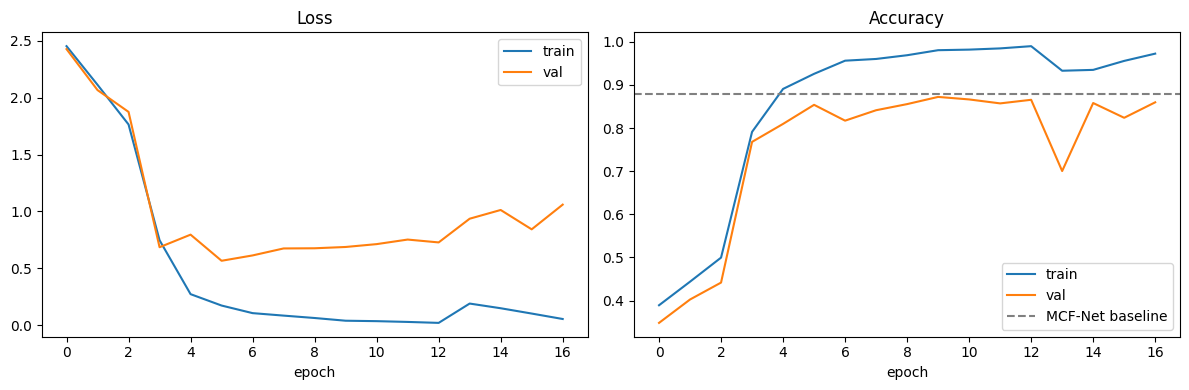

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].axhline(CONFIG["BASELINE_ACCURACY"], color="gray", linestyle="--", label="MCF-Net baseline")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend()
plt.tight_layout()
plt.show()


## 8. Final evaluation on the FULL official EyeQ test split

Training/early-stopping above used a small subset (`val_df`) purely for speed. This section
reloads the best checkpoint and evaluates on **every image in the official EyeQ test split**
(`test_df_full`) — a single inference pass, no training — so the reported accuracy is the
one that's actually comparable to the MCF-Net ~0.88 baseline.


In [ ]:
# Full test set, no augmentation, no in-memory caching (only used once, so caching isn't worth the RAM/setup time)
test_dataset_full = EyeQDataset(test_df_full, CONFIG["TEST_IMG_DIR"], transform=eval_transform,
                                 cache_in_memory=False)
test_loader_full = DataLoader(
    test_dataset_full, batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=True,
)

# Reload best checkpoint (in case training continued past the best epoch)
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader_full:
        imgs = imgs.to(device)
        with autocast(enabled=CONFIG["USE_AMP"]):
            outputs = model(imgs)
        probs = F.softmax(outputs.float(), dim=1)
        preds = probs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Full official test-set accuracy: {test_acc:.4f}  vs baseline {CONFIG['BASELINE_ACCURACY']}  "
      f"({'BEATS' if test_acc >= CONFIG['BASELINE_ACCURACY'] else 'BELOW'} baseline)")
print(f"(Trained on a {len(train_df)}-image stratified subset of the {len(train_df_full)}-image "
      f"full EyeQ train set — evaluated here on all {len(test_df_full)} official test images.)")

target_names = [QUALITY_LABELS[i] for i in range(CONFIG["NUM_CLASSES"])]
report = classification_report(all_labels, all_preds, target_names=target_names, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=target_names))


Indexed 16249 files in test_images in 17.9s


/tmp/ipykernel_641/73642606.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["USE_AMP"]):


Full official test-set accuracy: 0.8443  vs baseline 0.88  (BELOW baseline)
(Trained on a 6000-image stratified subset of the 12543-image full EyeQ train set — evaluated here on all 16249 official test images.)
              precision    recall  f1-score   support

        Good       0.94      0.87      0.90      8471
      Usable       0.70      0.78      0.74      4558
      Reject       0.82      0.87      0.84      3220

    accuracy                           0.84     16249
   macro avg       0.82      0.84      0.83     16249
weighted avg       0.85      0.84      0.85     16249



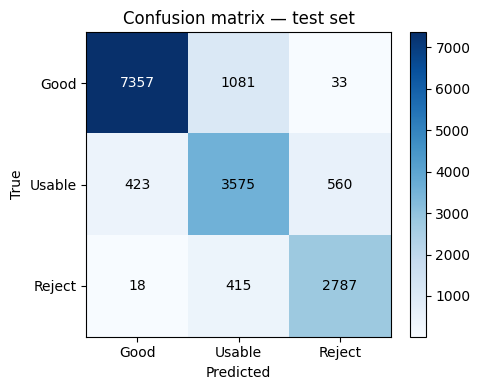

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(target_names))); ax.set_xticklabels(target_names)
ax.set_yticks(range(len(target_names))); ax.set_yticklabels(target_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im)
plt.title("Confusion matrix — test set")
plt.tight_layout()
plt.show()


In [ ]:
eval_report = {
    "test_accuracy": test_acc,
    "baseline_accuracy": CONFIG["BASELINE_ACCURACY"],
    "beats_baseline": bool(test_acc >= CONFIG["BASELINE_ACCURACY"]),
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "class_order": target_names,
    "train_subset_size": len(train_df),
    "train_full_size": len(train_df_full),
    "val_monitoring_subset_size": len(val_df),
    "test_set_size_full": len(test_df_full),
    "used_subset_for_training": bool(CONFIG["USE_SUBSET"]),
}
with open(Path(CONFIG["OUTPUT_DIR"]) / "eval_report.json", "w") as f:
    json.dump(eval_report, f, indent=2)

print("Saved eval_report.json")


Saved eval_report.json


## 9. Export for pipeline integration

Saves a `config.json` alongside `model.pt` describing exactly how to preprocess inputs and
decode outputs, so the FastAPI Stage 1 service can load this checkpoint without guessing
architecture, image size, normalization stats, or the class-index mapping.


In [ ]:
export_config = {
    "stage": "stage1_quality",
    "model_arch": CONFIG["MODEL_ARCH"],
    "timm_pretrained_base": True,
    "num_classes": CONFIG["NUM_CLASSES"],
    "img_size": CONFIG["IMG_SIZE"],
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "class_idx_to_label": QUALITY_LABELS,   # {0: "Good", 1: "Usable", 2: "Reject"}
    "decision_logic": {
        "Reject": "hard_stop_return_reason",
        "Usable": "enhance_clahe_illum_norm_then_stage2",
        "Good": "straight_to_stage2",
    },
    "test_accuracy": test_acc,
    "checkpoint_file": "model.pt",
    "trained_on": f"EyeQ official train split — stratified {len(train_df)}-image subset "
                  f"(full split has {len(train_df_full)} images)",
    "evaluated_on": f"EyeQ official FULL test split ({len(test_df_full)} images)",
}

with open(Path(CONFIG["OUTPUT_DIR"]) / "config.json", "w") as f:
    json.dump(export_config, f, indent=2)

print("Exported to:", CONFIG["OUTPUT_DIR"])
print(json.dumps(export_config, indent=2, default=str))


Exported to: /content/drive/MyDrive/dr_screening_pipeline/stage1_quality
{
  "stage": "stage1_quality",
  "model_arch": "efficientnet_b0",
  "timm_pretrained_base": true,
  "num_classes": 3,
  "img_size": 224,
  "normalize_mean": [
    0.485,
    0.456,
    0.406
  ],
  "normalize_std": [
    0.229,
    0.224,
    0.225
  ],
  "class_idx_to_label": {
    "0": "Good",
    "1": "Usable",
    "2": "Reject"
  },
  "decision_logic": {
    "Reject": "hard_stop_return_reason",
    "Usable": "enhance_clahe_illum_norm_then_stage2",
    "Good": "straight_to_stage2"
  },
  "test_accuracy": 0.8442981106529632,
  "checkpoint_file": "model.pt",
  "trained_on": "EyeQ official train split \u2014 stratified 6000-image subset (full split has 12543 images)",
  "evaluated_on": "EyeQ official FULL test split (16249 images)"
}


In [ ]:
def load_inference_model(output_dir, device=device):
    """Reference loader — mirrors what the FastAPI Stage 1 service should do."""
    output_dir = Path(output_dir)
    with open(output_dir / "config.json") as f:
        cfg = json.load(f)

    m = timm.create_model(cfg["model_arch"], pretrained=False, num_classes=cfg["num_classes"])
    ckpt = torch.load(output_dir / "model.pt", map_location=device)
    m.load_state_dict(ckpt["model_state_dict"])
    m.to(device).eval()
    return m, cfg

def predict_quality(model, cfg, image_bgr):
    """Given a raw cv2-loaded BGR image, return {label, confidence, probs}."""
    from PIL import Image
    img_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    tfm = T.Compose([
        ToPIL(),
        T.Resize((cfg["img_size"], cfg["img_size"])),
        T.ToTensor(),
        T.Normalize(mean=cfg["normalize_mean"], std=cfg["normalize_std"]),
    ])
    x = tfm(img_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1)[0].cpu().numpy()
    idx = int(probs.argmax())
    return {
        "label": cfg["class_idx_to_label"][str(idx)] if isinstance(list(cfg["class_idx_to_label"].keys())[0], str) else cfg["class_idx_to_label"][idx],
        "confidence": float(probs[idx]),
        "probs": {cfg["class_idx_to_label"].get(str(i), cfg["class_idx_to_label"].get(i)): float(p) for i, p in enumerate(probs)},
    }

# Smoke test: reload from disk exactly as the FastAPI service will, run on one test image
_m, _cfg = load_inference_model(CONFIG["OUTPUT_DIR"])
_sample_row = test_df.sample(1, random_state=SEED).iloc[0]
_img = cv2.imread(str(EyeQDataset(test_df, CONFIG["TEST_IMG_DIR"])._resolve_path(_sample_row["filename"])))
result = predict_quality(_m, _cfg, _img)
print("Ground truth:", QUALITY_LABELS[_sample_row["label"]])
print("Prediction:  ", result)


Indexed 16249 files in test_images in 7.2s
Ground truth: Reject
Prediction:   {'label': 'Reject', 'confidence': 0.9999877214431763, 'probs': {'Good': 4.048732269584798e-12, 'Usable': 1.225516007252736e-05, 'Reject': 0.9999877214431763}}


Image quality enhancement

Saving 38397_right.jpeg to 38397_right.jpeg


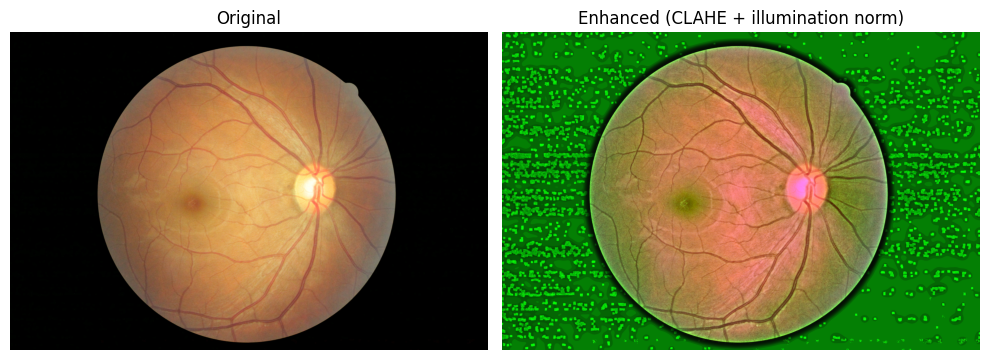

In [ ]:
# ============================================================
# Standalone image enhancement — CLAHE + illumination normalization
# No dependency on Stage 1 model or any other notebook section.
# Pick an image file from your computer, get the enhanced image back.
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

def clahe_illumination_normalize(img_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    """CLAHE (contrast, on LAB L-channel) + green-channel illumination normalization."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge([l_eq, a, b]), cv2.COLOR_LAB2BGR)

    b_ch, g_ch, r_ch = cv2.split(img_clahe)
    g_blur = cv2.GaussianBlur(g_ch, (0, 0), sigmaX=30)
    g_norm = cv2.divide(g_ch.astype(np.float32), g_blur.astype(np.float32) + 1e-6)
    g_norm = np.clip(g_norm * 128, 0, 255).astype(np.uint8)
    return cv2.merge([b_ch, g_norm, r_ch])


# --- pick a file from your computer ---
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)
assert img is not None, f"Could not read {img_path} — is it a valid image file?"

enhanced = clahe_illumination_normalize(img)

# --- show original vs enhanced ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
axes[1].set_title("Enhanced (CLAHE + illumination norm)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Notes for integrating into the FastAPI backend

- Copy the whole `stage1_quality/` folder (from `OUTPUT_DIR`) into the backend's model store.
- The FastAPI Stage 1 endpoint should load `config.json` + `model.pt` at startup using
  the same `load_inference_model` pattern above — don't hardcode architecture/size/norm
  stats in two places.
- Wire the classical pre-filters (`laplacian_variance`, `quadrant_histogram_spread` from
  section 4) directly into the `<2s` fast path ahead of the CNN call, per the architecture
  doc's SLA note.
- The `decision_logic` block in `config.json` documents routing (`Reject` → hard stop,
  `Usable` → CLAHE + illumination norm before Stage 2, `Good` → straight to Stage 2) — keep
  the actual enhancement implementation in the backend, this notebook only trains the
  classifier.
- Stage 3 will need its own notebook trained on `DR_grade` labels from this same EyeQ CSV —
  same dataset, different target column, same "official split" discipline. The subset +
  caching + AMP + progressive-unfreeze pattern here should carry over directly.

### On the subset/fast-mode tradeoffs
- **Why this stays close to full-dataset accuracy:** the backbone starts from ImageNet
  pretraining (not from scratch), the task is a coarse 3-way quality judgement rather than
  fine-grained lesion detection, and evaluation is always on the full official test set —
  so `MAX_TRAIN_SAMPLES` mainly affects training *time*, not what's being measured.
- **If accuracy comes in noticeably below baseline:** raise `MAX_TRAIN_SAMPLES` first (the
  single biggest lever), then try `FREEZE_BACKBONE_EPOCHS: 0` (fine-tune the whole network
  from epoch 1), then more `EPOCHS` with the same `EARLY_STOP_PATIENCE`.
- **If a session times out:** just re-run the CONFIG cell onward — the training-loop cell
  detects the saved checkpoint on Drive and offers to resume from the last completed epoch.
